In [20]:
import pandas as pd
import numpy as np

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [22]:
df = pd.read_csv('insurance.csv')

In [23]:
print("Data Preview:")
df.head()

Data Preview:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [24]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

In [25]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [26]:
print("Data after Preprocessing:")
df.head()

Data after Preprocessing:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [27]:
X = df.drop('charges', axis=1)
y = df['charges']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (1070, 8)
Testing set size: (268, 8)


In [30]:
model = LinearRegression()

In [31]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_pred = model.predict(X_test)

In [34]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [35]:
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared (Accuracy): {r2:.2f}")

Mean Squared Error: 33596915.85
R-squared (Accuracy): 0.78


In [37]:
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})

In [38]:
print("\nFirst 5 Predictions Comparison:")
print(comparison.head())


First 5 Predictions Comparison:
        Actual     Predicted
0   9095.06825   8969.550274
1   5272.17580   7068.747443
2  29330.98315  36858.410912
3   9301.89355   9454.678501
4  33750.29180  26973.173457


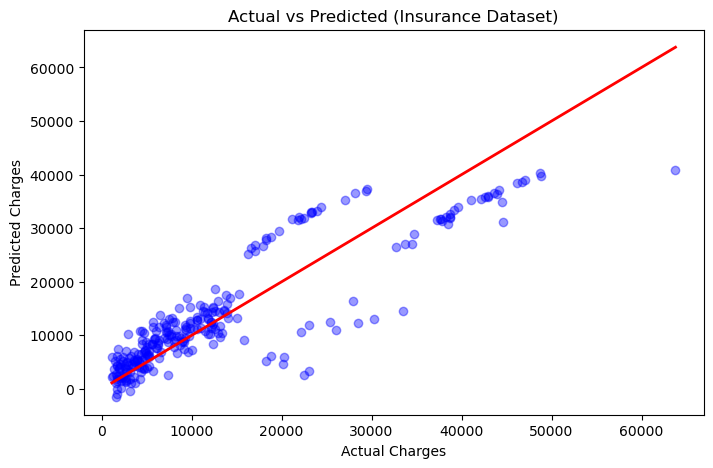

In [39]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted (Insurance Dataset)')
plt.show()